In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

RESULTS_DIR = "../results"

os.listdir(RESULTS_DIR)

['gemma3_latest_async_chain_results_validation.csv',
 'gemma3_latest_sync_chain_results_validation.csv',
 'llama3_2_latest_async_chain_results_validation.csv',
 'llama3_2_latest_sync_chain_results_validation.csv',
 'mistral_latest_async_chain_results_validation.csv',
 'mistral_latest_sync_chain_results_validation.csv',
 'phi4_latest_async_chain_results_validation.csv',
 'phi4_latest_sync_chain_results_validation.csv']

In [7]:
benchmark_df = pd.DataFrame()

for filename in os.listdir(RESULTS_DIR):
    df = pd.read_csv(os.path.join(RESULTS_DIR, filename))
    
    model_name = "_".join(filename.split('/')[-1].split('_')[0:2])
    df['ModelName'] = model_name
    
    is_async = 'async' in filename
    df["Algorithm"] = "Async" if is_async else "Sync"
    
    benchmark_df = pd.concat([benchmark_df, df])
    
benchmark_df.head()

,RowID,ErrorOccurred,ExecutionOutput,HasTimedOut,ExecutionError,ExecutionTime,ExpectedOutput,ActualOutput,CorrectOutput,FirstOutput,ModelName,Algorithm
0,511,False,NaN,False,NaN,30.005577,15,NaN,False,30.005577,gemma3_latest,Async
1,511,False,3\n,False,NaN,1.403515,2,3,False,1.214171,gemma3_latest,Async
2,512,False,"{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}\n",False,NaN,1.389822,"{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}","{6: 2, 7: 2, 8: 1, 9: 1, 10: 2}",True,0.867006,gemma3_latest,Async
3,512,False,"{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}\n",False,NaN,1.401132,"{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}","{7: 2, 8: 2, 9: 1, 10: 1, 11: 2}",True,0.883286,gemma3_latest,Async
4,513,False,"[12, 'PF', 13, 'PF', 14, 'PF', 15, 'PF']\n",False,NaN,1.474668,"[7, 'PF', 8, 'PF', 9, 'PF', 10, 'PF']","[12, 'PF', 13, 'PF', 14, 'PF', 15, 'PF']",False,1.172609,gemma3_latest,Async


In [8]:
# benchmark_df[benchmark_df["Algorithm"] == "Async"].groupby(by=benchmark_df["ModelName"])

benchmark_df.groupby(["ModelName", "Algorithm"])["ExecutionTime"].describe()

count      mean       std       min       25%  \
ModelName      Algorithm                                                  
gemma3_latest  Async      113.0  3.118605  6.518393  0.605181  1.155431   
               Sync       113.0  3.101047  6.468311  0.604042  1.150314   
llama3_2       Async      113.0  0.544600  0.520192  0.207981  0.357701   
               Sync       113.0  5.736692  5.620294  0.710194  1.530711   
mistral_latest Async      113.0  2.477018  1.014996  1.140326  1.846438   
               Sync       113.0  2.557761  0.893444  1.106978  1.936649   
phi4_latest    Async      113.0  5.757169  2.379056  3.388267  4.454360   
               Sync       113.0  6.198497  3.157714  3.583039  4.591494   

                               50%       75%        max  
ModelName      Algorithm                                 
gemma3_latest  Async      1.356923  1.852362  31.368442  
               Sync       1.337192  1.854031  30.013496  
llama3_2       Async      0.476587  0.613852   5.644623  
               Sync       3.057706  9.208368  30.175101  
mistral_latest Async      2.225319  2.704983   8.250166  
               Sync       2.346632  2.989459   6.153905  
phi4_latest    Async      5.550732  6.539410  26.696330  
               Sync       5.887364  6.864616  30.004457

In [ ]:
# First, create grouping for all data including ErrorOccurred
grouped = benchmark_df.groupby(["ModelName", "Algorithm", "ErrorOccurred"]).agg(
    Count=("ExecutionTime", "count"),
    Avg_ExecTime=("ExecutionTime", "mean"),
    Median_ExecTime=("ExecutionTime", "median"),
    Avg_FirstOutput=("FirstOutput", "mean"),
    Median_FirstOutput=("FirstOutput", "median")
).reset_index()

# Create additional grouping for non-error cases by CorrectOutput
non_error_df = benchmark_df[benchmark_df["ErrorOccurred"] == False]
grouped_correct = non_error_df.groupby(["ModelName", "Algorithm", "CorrectOutput"]).agg(
    Count=("ExecutionTime", "count"),
    Avg_ExecTime=("ExecutionTime", "mean"),
    Median_ExecTime=("ExecutionTime", "median"),
    Avg_FirstOutput=("FirstOutput", "mean"),
    Median_FirstOutput=("FirstOutput", "median")
).reset_index()

# Also get total error count per Model + Algorithm
error_summary = benchmark_df.groupby(["ModelName", "Algorithm"]).agg(
    ErrorCount=("ErrorOccurred", lambda x: (x == True).sum())
).reset_index()

# Merge the two summaries
final = pd.merge(grouped, error_summary, on=["ModelName", "Algorithm"], how="left")

print("Summary by ModelName, Algorithm, and ErrorOccurred:")
display(final)

print("\nSummary by ModelName, Algorithm, and CorrectOutput (non-error cases only):")
display(grouped_correct)

,ModelName,Algorithm,ErrorOccurred,Count,Avg_ExecTime,Median_ExecTime,Avg_FirstOutput,Median_FirstOutput,ErrorCount
0,gemma3_latest,Async,False,111,3.154407,1.356923,2.552142,1.077187,2
1,gemma3_latest,Async,True,2,1.131544,1.131544,0.947336,0.947336,2
2,gemma3_latest,Sync,False,111,3.135730,1.337192,3.135597,1.337061,2
3,gemma3_latest,Sync,True,2,1.176103,1.176103,1.176103,1.176103,2
4,llama3_2,Async,False,107,0.492344,0.476529,0.206955,0.206368,6
5,llama3_2,Async,True,6,1.476487,0.708811,0.188967,0.175218,6
6,llama3_2,Sync,False,108,5.375909,3.006472,5.363604,3.003628,5
7,llama3_2,Sync,True,5,13.529605,7.579711,13.529605,7.579711,5
8,mistral_latest,Async,False,104,2.490192,2.222190,0.850568,0.690420,9
9,mistral_latest,Async,True,9,2.324779,2.261999,1.580108,1.309868,9


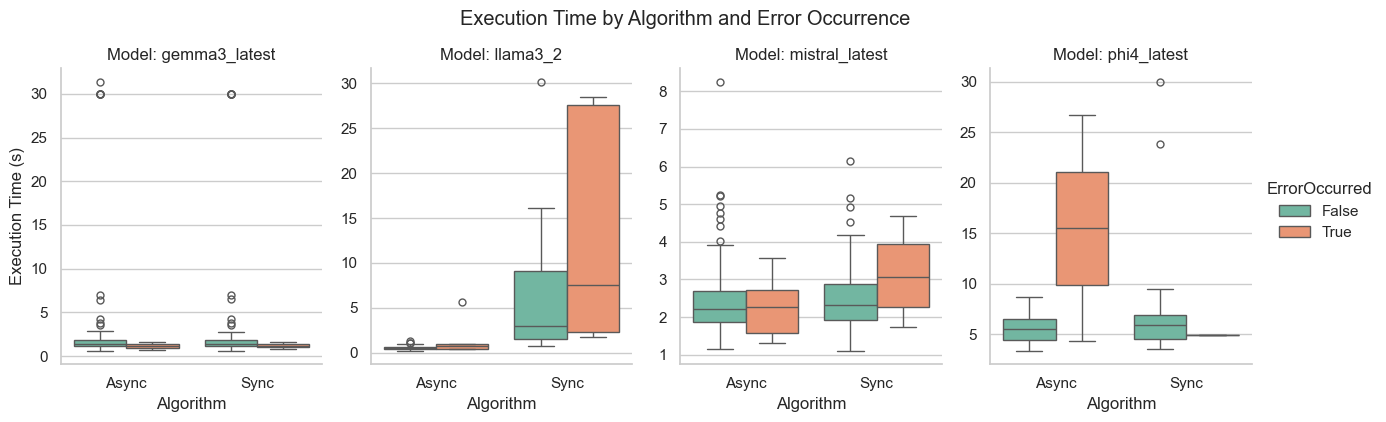

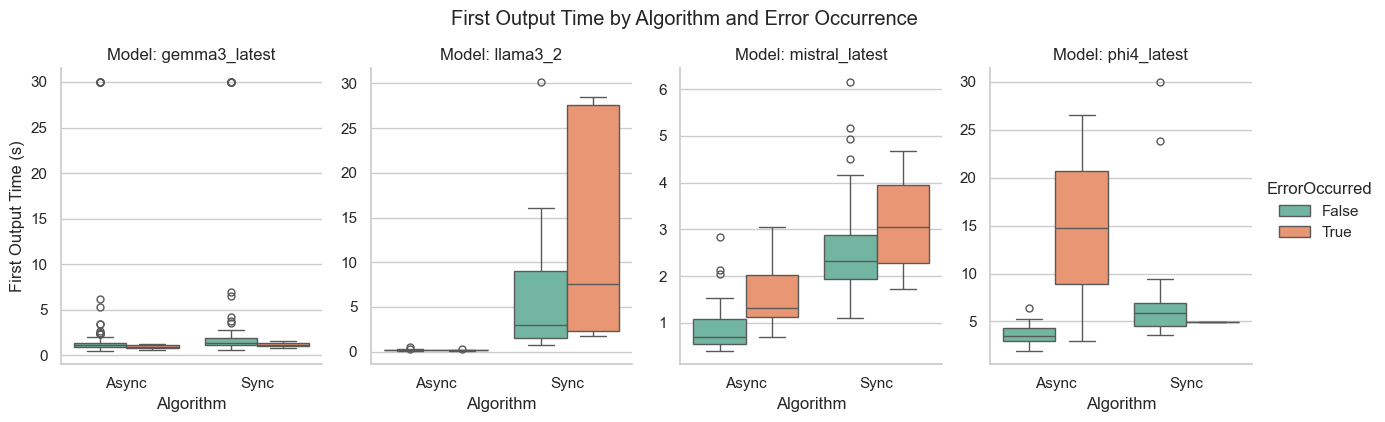

In [10]:
sns.set(style="whitegrid")

# --- Boxplot for ExecutionTime ---
g_exec = sns.catplot(
    data=benchmark_df, 
    x='Algorithm', 
    y='ExecutionTime', 
    hue='ErrorOccurred', 
    col='ModelName', 
    kind='box',
    height=4, 
    aspect=0.8,
    palette='Set2',
    sharey=False
)
g_exec.set_titles("Model: {col_name}")
g_exec.fig.suptitle('Execution Time by Algorithm and Error Occurrence', y=1.05)
g_exec.set_axis_labels("Algorithm", "Execution Time (s)")
plt.show()

# --- Boxplot for FirstOutput ---
g_first = sns.catplot(
    data=benchmark_df, 
    x='Algorithm', 
    y='FirstOutput', 
    hue='ErrorOccurred', 
    col='ModelName', 
    kind='box',
    height=4, 
    aspect=0.8,
    palette='Set2',
    sharey=False
)
g_first.set_titles("Model: {col_name}")
g_first.fig.suptitle('First Output Time by Algorithm and Error Occurrence', y=1.05)
g_first.set_axis_labels("Algorithm", "First Output Time (s)")
plt.show()

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(async_chain_results['ExecutionTime'], bins=20, kde=True)
plt.title('(Async) Distribution of Execution Times')
plt.xlabel('Execution Time (seconds)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(sync_chain_results['ExecutionTime'], bins=20, kde=True)
plt.title('(Sync) Distribution of Execution Times')
plt.xlabel('Execution Time (seconds)')
plt.ylabel('Frequency')
plt.show()

NameError: name 'async_chain_results' is not defined

<Figure size 1000x600 with 0 Axes>

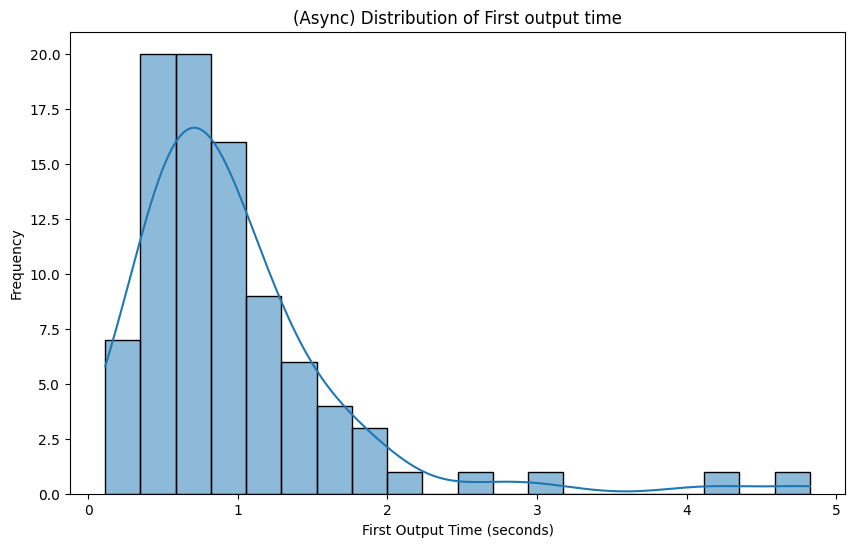

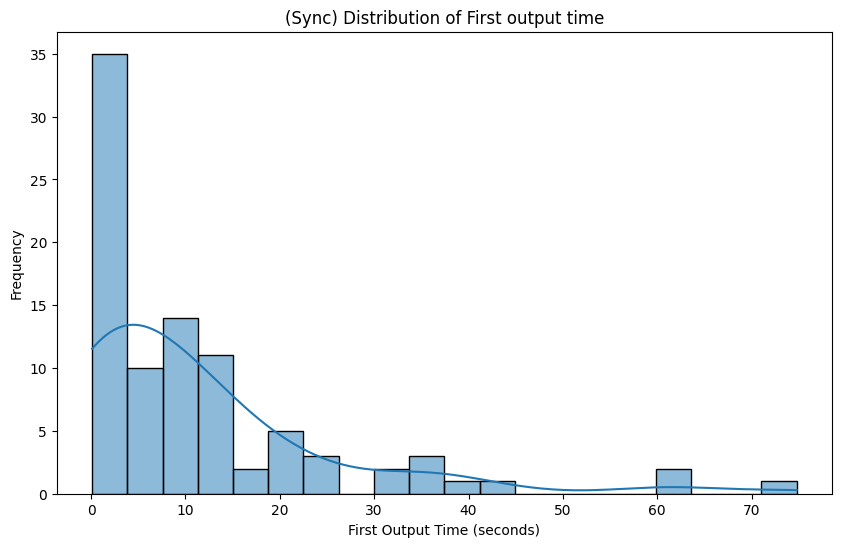

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(async_chain_results['FirstOutput'], bins=20, kde=True)
plt.title('(Async) Distribution of First output time')
plt.xlabel('First Output Time (seconds)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(sync_chain_results['FirstOutput'], bins=20, kde=True)
plt.title('(Sync) Distribution of First output time')
plt.xlabel('First Output Time (seconds)')
plt.ylabel('Frequency')
plt.show()

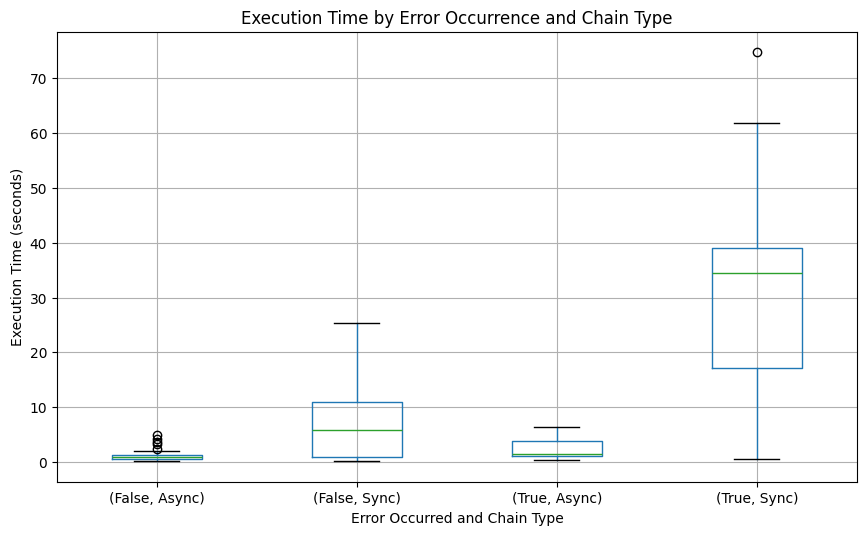

In [ ]:
# Assume async_chain_results and sync_chain_results are your existing DataFrames.
# Add a column to each indicating the chain type.
async_chain_results = async_chain_results.copy()
async_chain_results['ChainType'] = 'Async'

sync_chain_results = sync_chain_results.copy()
sync_chain_results['ChainType'] = 'Sync'

# Combine the two DataFrames into one.
combined_results = pd.concat([async_chain_results, sync_chain_results], ignore_index=True)

# Create a grouped boxplot using the built-in pandas plotting method.
fig, ax = plt.subplots(figsize=(10, 6))
combined_results.boxplot(column='ExecutionTime', by=['ErrorOccurred', 'ChainType'], ax=ax)
plt.title('Execution Time by Error Occurrence and Chain Type')
plt.suptitle('')  # Remove the automatic subtitle added by pandas
plt.xlabel('Error Occurred and Chain Type')
plt.ylabel('Execution Time (seconds)')
plt.show()